In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [3]:
from google.colab import files
uploaded = files.upload()

Saving titanic.csv to titanic.csv


In [4]:
df = pd.read_csv('titanic.csv')
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [5]:
survival_counts = df['Survived'].value_counts()

print("Survival Counts:\n", survival_counts)

Survival Counts:
 Survived
0    549
1    342
Name: count, dtype: int64


/tmp/ipykernel_17151/2464647975.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Survived', data=df, palette='pastel')


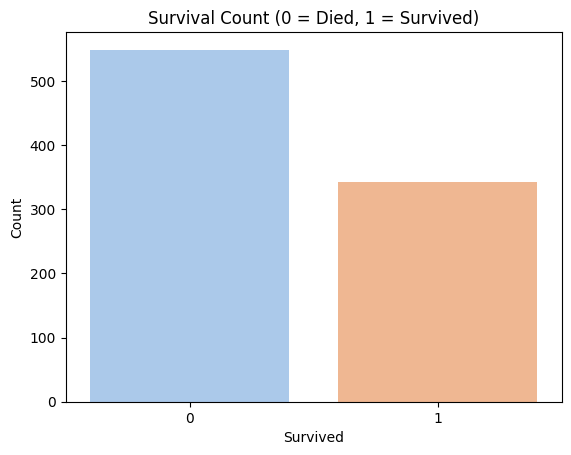

In [6]:
sns.countplot(x='Survived', data=df, palette='pastel')
plt.title('Survival Count (0 = Died, 1 = Survived)')
plt.xlabel('Survived')
plt.ylabel('Count')
plt.show()

In [8]:
gender_counts = df['Sex'].value_counts()
print("\nGender Counts:\n", gender_counts)


Gender Counts:
 Sex
male      577
female    314
Name: count, dtype: int64


In [9]:
survival_by_gender = df.groupby(['Sex', 'Survived']).size()
print("\nSurvival by Gender:\n", survival_by_gender)


Survival by Gender:
 Sex     Survived
female  0            81
        1           233
male    0           468
        1           109
dtype: int64


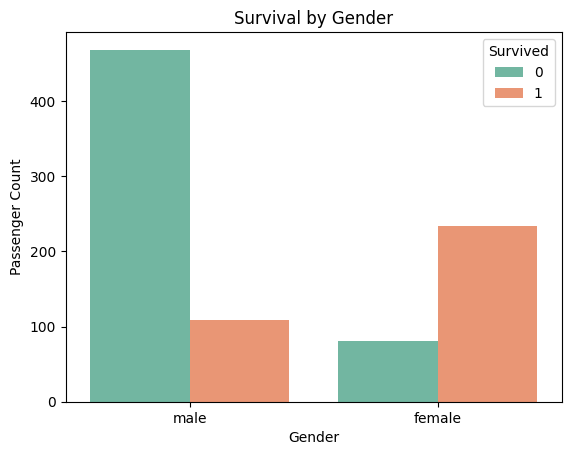

In [10]:
sns.countplot(x='Sex', hue='Survived', data=df, palette='Set2')
plt.title('Survival by Gender')
plt.xlabel('Gender')
plt.ylabel('Passenger Count')
plt.legend(title='Survived')
plt.show()

In [11]:
pclass_counts = df['Pclass'].value_counts()
print("\nPassenger Class Counts:\n", pclass_counts)


Passenger Class Counts:
 Pclass
3    491
1    216
2    184
Name: count, dtype: int64


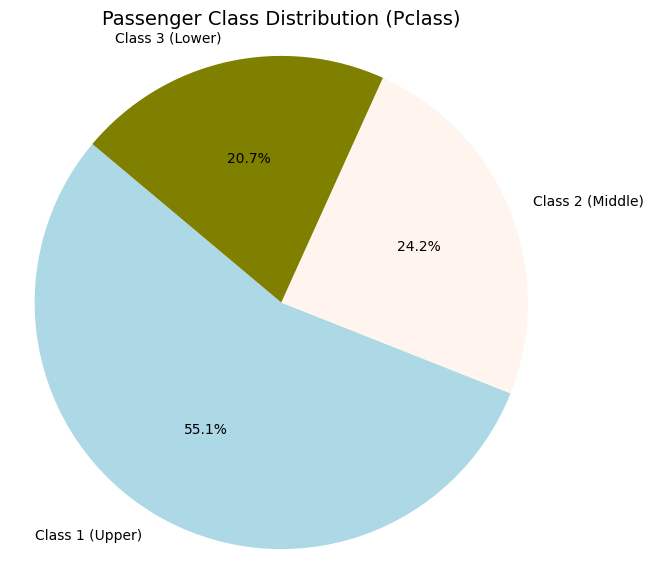

In [13]:
labels = ['Class 1 (Upper)', 'Class 2 (Middle)', 'Class 3 (Lower)']

plt.figure(figsize=(7, 7))
plt.pie(pclass_counts, labels=labels, autopct='%1.1f%%', startangle=140, colors=['lightblue', 'seashell', 'olive'])
plt.title('Passenger Class Distribution (Pclass)', fontsize=14)
plt.axis('equal')  # Ensures it's a circle
plt.show()

In [14]:
df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


In [15]:
df = df.drop(columns=['Cabin'])
df['Age'] = df['Age'].fillna(df['Age'].median())
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])

In [16]:
label = LabelEncoder()
df['Sex'] = label.fit_transform(df['Sex'])
df['Embarked'] = label.fit_transform(df['Embarked'])


In [17]:
X = df[['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare']]
y = df['Survived']

In [18]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [19]:
model = LogisticRegression(max_iter=500)
model.fit(X_train, y_train)

LogisticRegression(max_iter=500)

In [20]:
y_pred = model.predict(X_test)

In [21]:
accuracy = accuracy_score(y_test, y_pred)
accuracy

0.8100558659217877

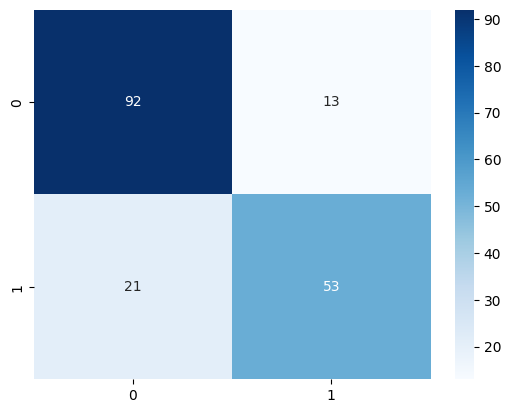

In [22]:
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.show()

In [23]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.81      0.88      0.84       105
           1       0.80      0.72      0.76        74

    accuracy                           0.81       179
   macro avg       0.81      0.80      0.80       179
weighted avg       0.81      0.81      0.81       179



In [25]:
sample = np.array([[3, 0, 22, 1, 0, 7.25]])
prediction = model.predict(sample)

if prediction[0] == 1:
  print("Survived")
else:
  print("Not Survived")

Survived


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(
